<a href="https://colab.research.google.com/github/jessiepsx/Machine-Learning-Practitioner/blob/main/Reconhecimento_Facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#required libraries
!pip install tensorflow==2.19.0 opencv-python-headless==4.8.0.76 mtcnn==0.1.1 scikit-learn==1.6.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.8.0.76
    Uninstalling opencv-python-headless-4.8.0.76:
      Successfully uninstalled opencv-python-headless-4.8.0.76


In [3]:

#Import necessary libraries
import os
import numpy as np
import cv2
from mtcnn import MTCNN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [16]:
# Instalar a biblioteca
!pip install bing-image-downloader

# Importar
from bing_image_downloader import downloader

# Criar pasta com 20 imagens da Evie
downloader.download("Evie Descendentes", limit=50, output_dir='imagens', adult_filter_off=True, force_replace=False, timeout=60)

# Criar pasta com 20 imagens da Mal
downloader.download("Mal Descendentes", limit=50, output_dir='imagens', adult_filter_off=True, force_replace=False, timeout=60)


[%] Downloading Images to /content/imagens/Evie Descendentes


[!!]Indexing page: 1

[%] Indexed 35 Images on Page 1.


[%] Downloading Image #1 from https://vignette.wikia.nocookie.net/descendentes-brasil/images/2/2c/Evie_Descendentes.png/revision/latest?cb=20170205174225&amp;path-prefix=pt-br
[!] Issue getting: https://vignette.wikia.nocookie.net/descendentes-brasil/images/2/2c/Evie_Descendentes.png/revision/latest?cb=20170205174225&amp;path-prefix=pt-br
[!] Error:: HTTP Error 404: Not Found
[%] Downloading Image #1 from https://vignette4.wikia.nocookie.net/disneydescendentes/images/7/70/Evie_Descendants.png/revision/latest?cb=20150818185226&amp;path-prefix=pt-br
[!] Issue getting: https://vignette4.wikia.nocookie.net/disneydescendentes/images/7/70/Evie_Descendants.png/revision/latest?cb=20150818185226&amp;path-prefix=pt-br
[!] Error:: HTTP Error 404: Not Found
[%] Downloading Image #1 from https://i.pinimg.com/736x/01/49/3b/01493b2b722f3c2a0175f21003fcb89a.jpg
[%] File Downloaded !


In [18]:

#Define characters and create dataset structure
characters = ['Evie', 'Mal']
num_classes = len(characters)

def create_dataset_structure():
    base_dir = '/content/imagens'
    if not os.path.exists(base_dir):
        os.makedirs(base_dir)

    for character in characters:
        char_dir = os.path.join(base_dir, character)
        if not os.path.exists(char_dir):
            os.makedirs(char_dir)

    print("Please upload character images to their respective folders in /content/imagens/")
    return base_dir

dataset_path = create_dataset_structure()

Please upload character images to their respective folders in /content/imagens/


In [40]:
detector = MTCNN()

def extract_face(image, required_size=(224, 224)):
    faces = detector.detect_faces(image)
    if faces:
        x, y, width, height = faces[0]['box']
        face = image[y:y+height, x:x+width]
        face = cv2.resize(face, required_size)
        return face
    return None

def prepare_data(dataset_path):
    X, y = [], []
    for character in characters:
        character_path = os.path.join(dataset_path, character)
        for image_name in os.listdir(character_path):
            image_path = os.path.join(character_path, image_name)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            face = extract_face(image)
            if face is not None:
                X.append(face)
                y.append(characters.index(character))
    return np.array(X), np.array(y)

# Load and prepare the data
X, y = prepare_data(dataset_path)

# Preprocess the data
X = X.astype('float32') / 255.0

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1

In [41]:

#Create and compile the model
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [45]:

#Train the model
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.7563 - loss: 0.6696 - val_accuracy: 0.8000 - val_loss: 0.6726 - learning_rate: 4.0000e-06
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.7297 - loss: 0.6692 - val_accuracy: 0.7000 - val_loss: 0.6726 - learning_rate: 4.0000e-06
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.6615 - loss: 0.6703 - val_accuracy: 0.6500 - val_loss: 0.6726 - learning_rate: 4.0000e-06
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 8s/step - accuracy: 0.6865 - loss: 0.6674 - val_accuracy: 0.7000 - val_loss: 0.6724 - learning_rate: 4.0000e-06
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 8s/step - accuracy: 0.7042 - loss: 0.6680 - val_accuracy: 0.7000 - val_loss: 0.6723 - learning_rate: 4.0000e-06
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.7164 - loss: 0.6708 - val_accuracy: 0.8000 - val_loss: 0.6722 - learning_rate: 4.0000e-06
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 8s/step - accuracy: 0.6969 - loss: 0.6650 - val_

In [46]:

#Define function for face recognition
def recognize_faces(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(image)

    for face in faces:
        x, y, width, height = face['box']
        face_image = image[y:y+height, x:x+width]
        face_image = cv2.resize(face_image, (224, 224))
        face_image = np.expand_dims(face_image, axis=0)
        face_image = face_image.astype('float32') / 255.0

        prediction = model.predict(face_image)
        character = characters[np.argmax(prediction)]
        confidence = np.max(prediction)

        cv2.rectangle(image, (x, y), (x+width, y+height), (0, 255, 0), 2)
        cv2.putText(image, f'{character} ({confidence:.2f})', (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return image

Upload an image for testing


Saving duas6.jpg to duas6 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


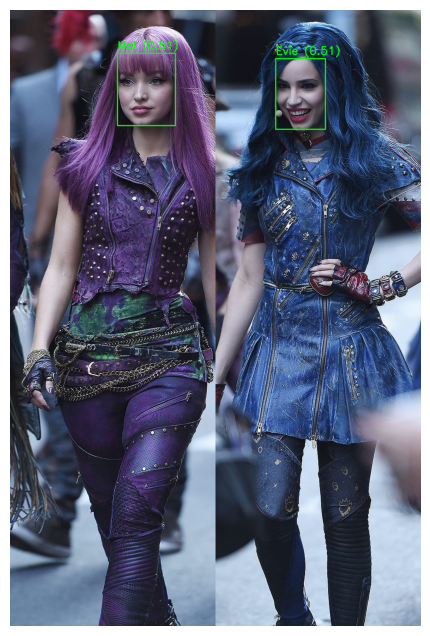

In [67]:
#Test the model
def test_recognition():
    print("Upload an image for testing")
    uploaded = files.upload()

    for filename in uploaded.keys():
        result = recognize_faces(filename)
        plt.figure(figsize=(12, 8))
        plt.imshow(result)
        plt.axis('off')
        plt.show()

test_recognition()